![](../img/330-banner.png)

# Lecture 11: Ensembles

UBC 2025-26

<blockquote>
The interests of truth require a diversity of opinions.    
    
by John Stuart Mill
</blockquote>



## Imports, announcements, LOs 

## Imports

In [1]:
import os

%matplotlib inline
import string
import sys
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.join(os.path.abspath(".."), "code"))

from plotting_functions import *
from sklearn import datasets
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from utils import *
DATA_DIR = os.path.join(os.path.abspath(".."), "data/")

import warnings
warnings.filterwarnings("ignore")

## Lecture learning objectives

From this lecture, you will be able to 

- Broadly explain the idea of ensembles 
- Explain how does predict work in the context of random forest models
- Explain the sources of randomness in random forest algorithm
- Explain the relation between number of estimators and the fundamental tradeoff in the context of random forests
- Use `scikit-learn`'s random forest classification and regression models and explain their main hyperparameters 
- Use other tree-based models such as as `XGBoost`, `LGBM` and `CatBoost`  
- Broadly explain ensemble approaches, in particular model averaging and stacking.
- Use `scikit-learn` implementations of these ensemble methods.

## Motivation [[video](https://youtu.be/8litm1H7DLo)]

### iClicker Exercise 11.0

Which of the following approaches is most effective when tackling a large project?

- (A) Working independently, relying solely on your own skills and judgment.
- (B) Collaborating with a group of people who think and work similarly to you.
- (C) Teaming up with a diverse group whose members bring different perspectives and complementary skills.

<br><br><br><br>

- **Ensembles** are models that combine multiple machine learning models to create more powerful models. 

<br><br>

### The Netflix prize

![](../img/netflix.png)

[Source](https://netflixtechblog.com/netflix-recommendations-beyond-the-5-stars-part-1-55838468f429)

Read the [story](https://lsa.umich.edu/social-solutions/diversity-democracy/oci-series/excerpts/volume-ii/the-netflix-prize.html) here. 

- Most of the winning solutions for Kaggle competitions involve some kind of ensembling. For example: 

<img src="../img/fraud_detection_kaggle.png" width="600" height="600">

Key idea: Groups can often make better decisions than individuals, especially when group members are diverse enough. 

[The Wisdom of Crowds](http://wisdomofcrowds.blogspot.com/2009/12/introduction-part-i.html)

<img src="../img/wisdom_of_crowds.jpg" width="300" height="300">

### Ensemble models 
- A number of ensemble models in ML literature.
- Most successful ones on a variety of datasets are tree-based models. 
- We'll briefly talk about two such tree-based models: 
    - **Random forests**
    - **Gradient boosted trees**
- We'll also talk about **averaging** and **stacking** (not tree based). 

### Tree-based models 

- Decision trees models are 
    - **Interpretable**
    - They can capture **non-linear** relationships
    - They **don't require scaling** of the data and theoretically can work with **categorical** features and missing values. 
- But single decision trees are likely to **overfit**.
- Idea: **Combine multiple trees** to build stronger models.
- These kinds of models are extremely popular in industry and machine learning competitions.

### Data

- Let's work with [the adult census data set](https://www.kaggle.com/uciml/adult-census-income). 

In [2]:
adult_df_large = pd.read_csv(DATA_DIR + "adult.csv")
train_df, test_df = train_test_split(adult_df_large, test_size=0.2, random_state=42)
train_df_nan = train_df.replace("?", np.nan)
test_df_nan = test_df.replace("?", np.nan)
train_df_nan.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
5514,26,Private,256263,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,25,United-States,<=50K
19777,24,Private,170277,HS-grad,9,Never-married,Other-service,Not-in-family,White,Female,0,0,35,United-States,<=50K
10781,36,Private,75826,Bachelors,13,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32240,22,State-gov,24395,Some-college,10,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,<=50K
9876,31,Local-gov,356689,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K


In [3]:
numeric_features = ["age", "capital.gain", "capital.loss", "hours.per.week"]

categorical_features = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "native.country",
]

ordinal_features = ["education"]
binary_features = ["sex"]
drop_features = ["fnlwgt", "race", "education.num"]
target_column = "income"

In [4]:
education_levels = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Prof-school",
    "Assoc-voc",
    "Assoc-acdm",
    "Some-college",
    "Bachelors",
    "Masters",
    "Doctorate",
]

In [5]:
assert set(education_levels) == set(train_df["education"].unique())

In [6]:
numeric_transformer = StandardScaler()

ordinal_transformer = OrdinalEncoder(categories=[education_levels], dtype=int)

binary_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(drop="if_binary", dtype=int),
)
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (ordinal_transformer, ordinal_features),
    (binary_transformer, binary_features),
    (categorical_transformer, categorical_features),
    ("drop", drop_features),
)

In [7]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('ordinalencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [8]:
X_train = train_df_nan.drop(columns=[target_column])
y_train = train_df_nan[target_column]

X_test = test_df_nan.drop(columns=[target_column])
y_test = test_df_nan[target_column]

### Do we have class imbalance? 

- There is class imbalance. But without any context, both classes seem equally important. 
- Let's use accuracy as our metric. 

In [9]:
train_df["income"].value_counts(normalize=True)

income
<=50K    0.757985
>50K     0.242015
Name: proportion, dtype: float64

In [10]:
scoring_metric = "accuracy"

We are going to use models outside sklearn. **Some of them cannot handle categorical target values**. So we'll convert them to integers using `LabelEncoder`. 

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_num = label_encoder.fit_transform(y_train)
y_test_num = label_encoder.transform(y_test)

In [12]:
y_train_num

array([0, 0, 0, ..., 1, 1, 0], shape=(26048,))

Let's store all the results in a dictionary called `results`. 

In [13]:
results = {}

### Baselines

####  `DummyClassifier` baseline

In [14]:
dummy = DummyClassifier()
results["Dummy"] = mean_std_cross_val_scores(
    dummy, X_train, y_train_num, return_train_score=True, scoring=scoring_metric
)

#### `DecisionTreeClassifier` baseline

- Let's try decision tree classifier on our data. 

In [15]:
pipe_dt = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=123))
results["Decision tree"] = mean_std_cross_val_scores(
    pipe_dt, X_train, y_train_num, return_train_score=True, scoring=scoring_metric
)
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
Dummy,0.006 (+/- 0.002),0.001 (+/- 0.000),0.758 (+/- 0.000),0.758 (+/- 0.000)
Decision tree,0.249 (+/- 0.031),0.023 (+/- 0.003),0.817 (+/- 0.006),0.979 (+/- 0.000)


Decision tree is clearly **overfitting**. 

<br><br><br><br>

## Random forests 

<img src="../img/eva-forest.jpg" width="300" height="350">

### General idea

- A single decision tree is likely to overfit
- Use a **collection of diverse** decision trees
- Each tree overfits on some part of the data but we can reduce overfitting by averaging the results 
    - can be shown mathematically

### `RandomForestClassifier` 

- Before understanding the details let's first try it out.  

In [16]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        n_jobs=-1,
        random_state=123,
    ),
)
results["Random forests"] = mean_std_cross_val_scores(
    pipe_rf, X_train, y_train_num, return_train_score=True, scoring=scoring_metric
)
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
Dummy,0.006 (+/- 0.002),0.001 (+/- 0.000),0.758 (+/- 0.000),0.758 (+/- 0.000)
Decision tree,0.249 (+/- 0.031),0.023 (+/- 0.003),0.817 (+/- 0.006),0.979 (+/- 0.000)
Random forests,0.849 (+/- 0.030),0.168 (+/- 0.009),0.847 (+/- 0.006),0.979 (+/- 0.000)


The validation scores are better although it seems likes we are **still overfitting**. 

### How do they work? 

- Decide how many decision trees we want to build
    - can control with `n_estimators` hyperparameter 
- `fit` a **diverse set** of that many decision trees by **injecting randomness** in the model construction (trees must be different for this to work!)
- `predict` by **voting** (classification) or **averaging** (regression) of predictions given by individual models

**Question:** what do you suggest to do to build different trees?

### Inject randomness in the classifier construction

To ensure that the trees in the random forest are different we inject randomness in two ways:  

1. Data: **Build each tree on a bootstrap sample** (i.e., a sample drawn **with replacement** from the training set)
2. Features: **At each node, select a random subset of features** (controlled by `max_features` in `scikit-learn`) and look for the best possible test involving one of these features   

### An example of a bootstrap samples

- Suppose you are training a random forest model with `n_estimators=3`. 
- Suppose this is your original dataset with six examples: [0,1,2,3,4,5]
- Each decision tree trains on a total of six examples.
- Each tree trains on a different set of examples. 

Below, you see a table representing each bootstrap sample. Try writing them as lists.

In [17]:
random_forest_data = {'original':[1, 1, 1, 1, 1, 1], 'tree1':[0, 2, 0, 3, 1, 0], 'tree2':[0, 2, 3, 1, 0, 0], 'tree3':[3, 0, 0, 0, 2, 1]}
pd.DataFrame(random_forest_data)

,original,tree1,tree2,tree3
0,1,0,0,3
1,1,2,2,0
2,1,0,3,0
3,1,3,1,0
4,1,1,0,2
5,1,0,0,1


#### Solution

- sample drawn with replacement for tree 1: [1,1,3,3,3,4]
- sample drawn with replacement for tree 2: [1,1,2,2,2,3]
- sample drawn with replacement for tree 3: [0,0,0,4,4,5]

### The random forests classifier 

***Training time***:
- Create a collection (**ensemble**) of trees.
    - Grow each tree on an independent **bootstrap sample from the data**.
- At each node:
    - Randomly select a **subset of features** out of all features (independently for each node).
    - Find the **best split** on the selected features.
    - Grow the trees to **maximum depth**.

***Prediction time***:
- **Vote** the trees to get predictions for new example.

### Example 

- Let's create a random forest with 3 estimators. 
- I'm using `max_depth=2` for easy visualization. 

In [18]:
pipe_rf_demo = make_pipeline(
    preprocessor, RandomForestClassifier(max_depth=2, n_estimators=3, random_state=123)
)
pipe_rf_demo.fit(X_train, y_train_num);

- Let's get the feature names of transformed features.

In [19]:
feature_names = (
    numeric_features
    + ordinal_features
    + binary_features
    + pipe_rf_demo.named_steps["columntransformer"]
    .named_transformers_["pipeline-2"]
    .named_steps["onehotencoder"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
pd.DataFrame(columns=feature_names)  # Take a look at the feature names

,age,capital.gain,capital.loss,hours.per.week,education,sex,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,native.country_missing


- Let's sample a test example where income > 50k. 

In [20]:
probs = pipe_rf_demo.predict_proba(X_test)
np.where(probs[:, 1] > 0.55)

(array([ 582, 1271, 1991, 2268, 2447, 2516, 2556, 4151, 4165, 5294, 5798,
        5970, 6480]),)

In [21]:
test_example = X_test.iloc[[582]]
pipe_rf_demo.predict_proba(test_example)
print("Classes: ", pipe_rf_demo.classes_)
print("Prediction by random forest: ", pipe_rf_demo.predict(test_example))
transformed_example = preprocessor.transform(test_example)
pd.DataFrame(data=transformed_example.flatten(), index=feature_names)

Classes:  [0 1]
Prediction by random forest:  [1]


,0
age,0.550004
capital.gain,-0.147166
capital.loss,-0.217680
hours.per.week,1.579660
education,15.000000
...,...
native.country_Trinadad&Tobago,0.000000
native.country_United-States,1.000000
native.country_Vietnam,0.000000
native.country_Yugoslavia,0.000000


- We can look at **different trees** created by random forest. 
- Note that each tree looks at **different set of features** and slightly **different data**.



Tree 1


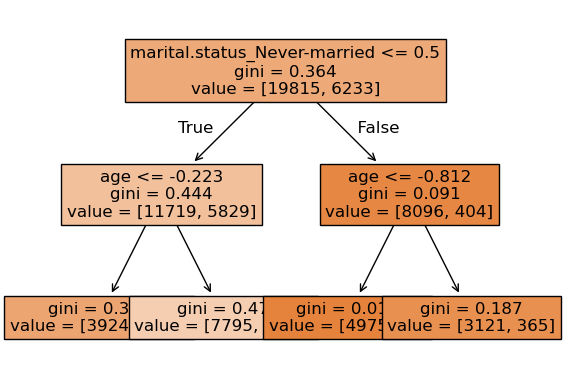

None

prediction [0.]


Tree 2


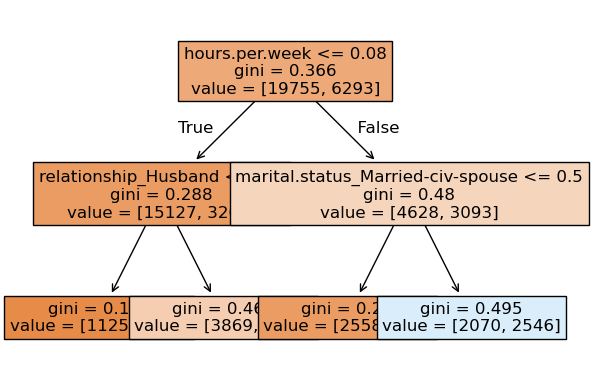

None

prediction [1.]


Tree 3


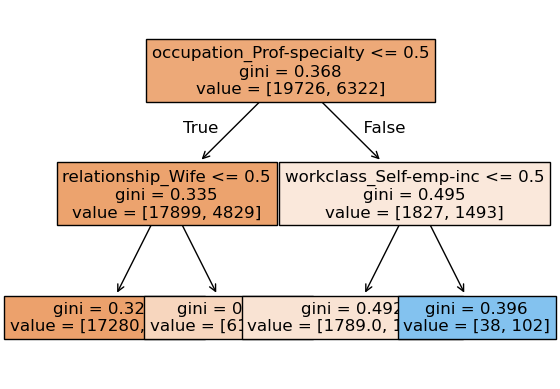

None

prediction [1.]


In [22]:
for i, tree in enumerate(
    pipe_rf_demo.named_steps["randomforestclassifier"].estimators_
):
    print("\n\nTree", i + 1)
    display(custom_plot_tree(tree, feature_names, fontsize=12))
    print("prediction", tree.predict(preprocessor.transform(test_example)))

### Some important hyperparameters:

- `n_estimators`: number of decision trees (higher = more complexity)
- `max_depth`: max depth of each decision tree (higher = more complexity)
- `max_features`: the number of features you get to look at each split (higher = more complexity)


### Random forests: number of trees (`n_estimators`) and the fundamental tradeoff 

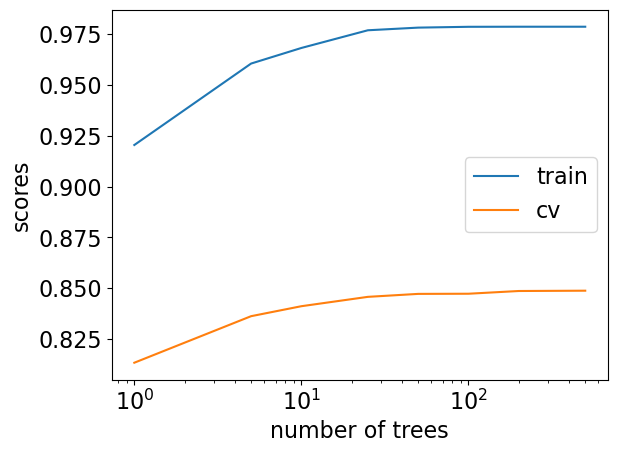

In [23]:
make_num_tree_plot(
    preprocessor, X_train, y_train, X_test, y_test, [1, 5, 10, 25, 50, 100, 200, 500]
) # User-defined function defined in code/plotting_functions.py 

#### Number of trees and fundamental trade-off

- Above: seems like we're beating the fundamental "tradeoff" by <br>**increasing training score** and **not decreasing validation score** much.
- You'll often see a high training scores for in the context of random forests. That's normal. It doesn't mean that the model is overfitting. 
- While ensembles often offer improved performance, this benefit isn't always guaranteed.
- Always opting for more trees in a random forest is preferable, but we sometimes choose fewer trees for faster performance.


### Strengths

- Usually **one of the best** performing **off-the-shelf** classifiers without heavy tuning of hyperparameters
- **Don't** require **scaling** of data 
- **Less** likely to **overfit**
- Slower than decision trees because we are fitting multiple trees but <br>**can easily parallelize training** because all trees are independent of each other
- In general, able to capture a much broader picture of the data compared to a single decision tree. 

### Weaknesses

- Require more memory 
- Hard to interpret
- Tend not to perform well on high dimensional sparse data such as text data


___
Make sure to set the `random_state` for reproducibility. Changing the `random_state` can have a big impact on the model and the results due to the random nature of these models. Having more trees can get you a more robust estimate.

[The original random forests paper](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf) by Leo Breiman. 
___

## ❓❓ Questions for you

### iClicker Exercise 11.1 

**Select the most accurate option below.**

- (A) Every tree in a random forest uses a different bootstrap sample of the training set.
- (B) To train a tree in a random forest, we first randomly select a subset of features. The tree is then restricted to only using those features.
- (C) The `n_estimators` hyperparameter of random forests should be tuned to get a better performance on the validation or test data.  
- (D) In random forests we build trees in a sequential fashion, where the current tree is dependent upon the previous tree.  
- (E) Let classifiers A, B, and C have training errors of 10%, 20%, and 30%, respectively. Then, the best possible training error from averaging A, B and C is 10%.

<br><br><br><br>

## Gradient boosted trees [[video](https://youtu.be/EkFkY9QB2Hw)]

Another popular and effective class of tree-based models is gradient boosted trees. 

- **No** randomization.
- The key idea is:<br>combining many simple models called **weak learners to create a strong learner**
- They combine **multiple shallow** (depth 1 to 5) decision trees.
- They build trees in a **serial manner**, where each tree tries to **correct the mistakes** of the previous one.

We'll not go into the details. If you want to know more, here are some resources: 
- [UBC CPSC 340 Gradient Boosting notes](https://www.students.cs.ubc.ca/~cs-340/L24.pdf)
- [Gradient Boosted Decision Trees by Google Developer](https://developers.google.com/machine-learning/decision-forests/intro-to-gbdt)

We'll look at brief examples of using the following three gradient boosted tree models. 

- [XGBoost](https://xgboost.readthedocs.io/en/latest/)
- [LightGBM](https://lightgbm.readthedocs.io/en/latest/Python-Intro.html) 
- [CatBoost](https://catboost.ai/docs/concepts/python-quickstart.html)

### [XGBoost](https://xgboost.ai/about) 

- Not part of `sklearn` but has similar interface. 
- Install it in your conda environment: `conda install -n cpsc330 -c conda-forge xgboost`
- Supports missing values
- GPU training, networked parallel training
- Supports sparse data
- Typically better scores than random forests    

### [LightGBM](https://lightgbm.readthedocs.io/)

- Not part of `sklearn` but has similar interface. 
- Install it in your conda environment: `conda install -n cpsc330 -c conda-forge lightgbm`
- Small model size
- Faster 
- Typically better scores than random forests    

### [CatBoost](https://catboost.ai/)

- Not part of `sklearn` but has similar interface. 
- Install it in your course conda environment: `conda install -n cpsc330 -c conda-forge catboost`
- Usually better scores but slower compared to `XGBoost` and `LightGBM`     

### Important hyperparameters

- `n_estimators` $\rightarrow$ Number of boosting rounds
- `learning_rate` $\rightarrow$ The learning rate of training
    - controls how strongly each tree tries to correct the mistakes of the previous trees
    - higher learning rate means each tree can make stronger corrections, which means more complex model 
- `max_depth` $\rightarrow$ `max_depth` of trees (similar to decision trees) 
- `scale_pos_weight` $\rightarrow$ Balancing of positive and negative weights

In our demo below, we'll just give equal weight to both classes because we are trying to optimize accuracy. But if you want to give more weight to class 1, for example, you can calculate the data imbalance ratio and set `scale_pos_weight` hyperparameter with that weight. 

In [24]:
ratio = np.bincount(y_train_num)[0] / np.bincount(y_train_num)[1]
ratio

np.float64(3.1319796954314723)

### Gradient boosting in `sklearn`

sklearn also has gradient boosting models. 

- [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) and [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)
- [HistGradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) and [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor)  (Inspired by LGBM, supports missing values)

Let's try out all these models. 

In [25]:
from catboost import CatBoostClassifier
from lightgbm.sklearn import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

pipe_lr = make_pipeline(
    preprocessor, LogisticRegression(max_iter=2000, random_state=123)
)
pipe_dt = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=123))
pipe_rf = make_pipeline(
    preprocessor, RandomForestClassifier(class_weight="balanced", random_state=123)
)
pipe_xgb = make_pipeline(
    preprocessor,
    XGBClassifier(
        random_state=123, verbosity=0
    ),
)
pipe_lgbm = make_pipeline(
    preprocessor, LGBMClassifier(random_state=123, verbose=-1)
)

pipe_catboost = make_pipeline(
    preprocessor,
    CatBoostClassifier(verbose=0, random_state=123),
)

pipe_sklearn_histGB = make_pipeline(
    preprocessor,
    HistGradientBoostingClassifier(random_state=123),
)

pipe_sklearn_GB = make_pipeline(
    preprocessor,
    GradientBoostingClassifier(random_state=123),
)

classifiers = {
    "logistic regression": pipe_lr,
    "decision tree": pipe_dt,
    "random forest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm,
    "CatBoost": pipe_catboost,
    "sklearn_histGB": pipe_sklearn_histGB,
    "sklearn_GB": pipe_sklearn_GB,
}

In [26]:
import warnings

warnings.simplefilter(action="ignore", category=DeprecationWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

In [27]:
results = {}

In [28]:
dummy = DummyClassifier()
results["Dummy"] = mean_std_cross_val_scores(
    dummy, X_train, y_train, return_train_score=True, scoring=scoring_metric
)

In [29]:
for (name, model) in classifiers.items():
    results[name] = mean_std_cross_val_scores(
        model, X_train, y_train_num, return_train_score=True, scoring=scoring_metric
    )

In [30]:
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
Dummy,0.012 (+/- 0.001),0.006 (+/- 0.001),0.758 (+/- 0.000),0.758 (+/- 0.000)
logistic regression,0.877 (+/- 0.141),0.020 (+/- 0.001),0.849 (+/- 0.005),0.850 (+/- 0.001)
decision tree,0.239 (+/- 0.005),0.023 (+/- 0.004),0.817 (+/- 0.006),0.979 (+/- 0.000)
random forest,2.525 (+/- 0.981),0.177 (+/- 0.008),0.844 (+/- 0.007),0.976 (+/- 0.001)
XGBoost,0.824 (+/- 0.650),0.030 (+/- 0.002),0.872 (+/- 0.004),0.897 (+/- 0.001)
LightGBM,0.269 (+/- 0.030),0.030 (+/- 0.003),0.872 (+/- 0.004),0.888 (+/- 0.000)
CatBoost,9.016 (+/- 1.836),0.008 (+/- 0.002),nan (+/- nan),nan (+/- nan)
sklearn_histGB,1.202 (+/- 0.203),0.039 (+/- 0.002),0.871 (+/- 0.005),0.887 (+/- 0.002)
sklearn_GB,3.867 (+/- 0.989),0.032 (+/- 0.002),0.864 (+/- 0.004),0.870 (+/- 0.001)


**Some observations**
- Keep in mind all these results are with default hyperparameters.
- **Ideally** we would carry out **hyperparameter optimization** for all of them and then compare the results. 
- We are using a particular scoring metric (accuracy in this case).
- We are scaling numeric features but it shouldn't matter for tree-based models.
- Look at the **standard deviation. Doesn't look very high**. 
    - The scores look more or less stable. 

In [31]:
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
Dummy,0.012 (+/- 0.001),0.006 (+/- 0.001),0.758 (+/- 0.000),0.758 (+/- 0.000)
logistic regression,0.877 (+/- 0.141),0.020 (+/- 0.001),0.849 (+/- 0.005),0.850 (+/- 0.001)
decision tree,0.239 (+/- 0.005),0.023 (+/- 0.004),0.817 (+/- 0.006),0.979 (+/- 0.000)
random forest,2.525 (+/- 0.981),0.177 (+/- 0.008),0.844 (+/- 0.007),0.976 (+/- 0.001)
XGBoost,0.824 (+/- 0.650),0.030 (+/- 0.002),0.872 (+/- 0.004),0.897 (+/- 0.001)
LightGBM,0.269 (+/- 0.030),0.030 (+/- 0.003),0.872 (+/- 0.004),0.888 (+/- 0.000)
CatBoost,9.016 (+/- 1.836),0.008 (+/- 0.002),nan (+/- nan),nan (+/- nan)
sklearn_histGB,1.202 (+/- 0.203),0.039 (+/- 0.002),0.871 (+/- 0.005),0.887 (+/- 0.002)
sklearn_GB,3.867 (+/- 0.989),0.032 (+/- 0.002),0.864 (+/- 0.004),0.870 (+/- 0.001)


In [32]:
# comparison of results

results_df = pd.DataFrame(results).T[1:]   # exclude the the 'Dummy' row [1:]

# To find ordering, extract only numerical value (throwing away standard deviation information)
cv_score_order = results_df['test_score'].str.extract(r'(\d*\.\d+)').squeeze().sort_values().index
print('\nCV scores:')
print(*cv_score_order, sep=' < ')

fit_time_order = results_df['fit_time'].str.extract(r'(\d*\.\d+)').squeeze().sort_values().index
print('\nFitting speeds:')
print(*fit_time_order, sep=' > ')


CV scores:
decision tree < random forest < logistic regression < sklearn_GB < sklearn_histGB < XGBoost < LightGBM < CatBoost

Fitting speeds:
decision tree > LightGBM > XGBoost > logistic regression > sklearn_histGB > random forest > sklearn_GB > CatBoost


- Decision trees and random forests overfit
    - Other models do not seem to overfit much. 
- Fit times
    - Decision trees are fast but not very accurate
    - LightGBM is faster than decision trees and more accurate! 
    - CatBoost fit time is highest. 
    - There is not much difference between the validation scores of XGBoost, LightGBM, and CatBoost.
    - Among the best performing models, LightGBM is the fastest one!
- Scores times  
    - Prediction times are much smaller in all cases. 

<br><br>

### Which model should I use?

**Simple answer**
- Whichever gets the highest CV score making sure that you're not overusing the validation set.

**Interpretability**
- This is an area of growing interest and concern in ML.
- How important is interpretability for you? 
- In the next class we'll talk about interpretability of non-linear models. 


**Speed/code maintenance**
- Other considerations could be speed (fit and/or predict), maintainability of the code.

Finally, you could use all of them!

<br><br><br><br>

## Averaging 

Earlier we looked at a bunch of classifiers:

In [33]:
classifiers.keys()

dict_keys(['logistic regression', 'decision tree', 'random forest', 'XGBoost', 'LightGBM', 'CatBoost', 'sklearn_histGB', 'sklearn_GB'])

For this demonstration, let's get rid of sklearn's gradient boosting models and CatBoost because it's too slow. 

In [34]:
del classifiers["sklearn_histGB"]
del classifiers["sklearn_GB"]
del classifiers["CatBoost"]

In [35]:
classifiers.keys()

dict_keys(['logistic regression', 'decision tree', 'random forest', 'XGBoost', 'LightGBM'])

What if we use all the models in `classifiers` and let them vote during prediction time? 

In [36]:
from sklearn.ensemble import VotingClassifier

averaging_model = VotingClassifier(
    list(classifiers.items()), voting="soft"
)  # need the list() here for cross-validation to work!

In [37]:
from sklearn import set_config

set_config(display="diagram")  # global setting

In [38]:
averaging_model

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('logistic regression', ...), ('decision tree', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('ordinalencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse mat

This `VotingClassifier` will take a _vote_ using the predictions of the constituent classifier pipelines.

Main parameter: `voting`
- `voting='hard'` 
    - it uses the output of `predict` and actually votes.
- `voting='soft'`
    - with `voting='soft'` it averages the output of `predict_proba` and then thresholds / takes the larger.

- The choice depends on whether you trust `predict_proba` from your base classifiers - if so, it's nice to access that information.

In [39]:
averaging_model.fit(X_train, y_train_num);

- What happens when you `fit` a `VotingClassifier`?
    - It will fit all constituent models.    

___
It seems sklearn requires us to actually call `fit` on the `VotingClassifier`, instead of passing in pre-fit models. This is an implementation choice rather than a conceptual limitation.
___

Let's look at particular test examples where `income` is ">50k" (y=1):

In [40]:
test_g50k = (
    test_df.query("income == '>50K'")
    .sample(4, random_state=42)
    .drop(columns=["income"])
)
test_l50k = (
    test_df.query("income == '<=50K'")
    .sample(4, random_state=2)
    .drop(columns=["income"])
)

In [41]:
averaging_model.classes_

array([0, 1])

What are the predictions given by the voting model? 

In [42]:
data = {"y": 1, "Voting classifier": averaging_model.predict(test_g50k)}
pd.DataFrame(data)

,y,Voting classifier
0,1,1
1,1,1
2,1,1
3,1,1


For hard voting, these are the votes:

In [43]:
r1 = {
    name: classifier.predict(test_g50k)
    for name, classifier in averaging_model.named_estimators_.items()
}
data.update(r1)
pd.DataFrame(data)

,y,Voting classifier,logistic regression,decision tree,random forest,XGBoost,LightGBM
0,1,1,1,1,1,1,1
1,1,1,0,1,1,1,0
2,1,1,1,0,1,1,1
3,1,1,1,0,1,1,1


For soft voting, these are the scores:

In [44]:
r2 = {
    name: classifier.predict_proba(test_g50k)[:, 1]
    for name, classifier in averaging_model.named_estimators_.items()
}

data.update(r2)
pd.DataFrame(data)

,y,Voting classifier,logistic regression,decision tree,random forest,XGBoost,LightGBM
0,1,1,0.663635,1.0,0.760000,0.669376,0.685786
1,1,1,0.247963,1.0,0.678924,0.581217,0.463582
2,1,1,0.636021,0.5,0.621537,0.684623,0.665882
3,1,1,0.615177,0.0,0.770000,0.679356,0.683015


(Aside: the probability scores from `DecisionTreeClassifier` are pretty bad)

What's the prediction probability of the averaging model? Let's examine prediction probability of the first example from `test_g50k`. 

In [45]:
averaging_model.predict_proba(test_g50k)[1]

array([0.40566285, 0.59433715])

It adds the prediction probabilities given by constituent models and divides the summation by the number of constituent models. 

In [46]:
# Sum of probabilities for class 0 at index 1
sum_prob_ex1_class_0 = np.sum(
    [
        classifier.predict_proba(test_g50k)[1][0]
        for name, classifier in averaging_model.named_estimators_.items()
    ]
)
sum_prob_ex1_class_0

np.float64(2.0283142374999237)

In [47]:
# Sum of probabilities for class 1 at index 1
sum_prob_ex1_class_1 = np.sum(
    [
        classifier.predict_proba(test_g50k)[1][1]
        for name, classifier in averaging_model.named_estimators_.items()
    ]
)
sum_prob_ex1_class_1

np.float64(2.9716857625000763)

In [48]:
n_constituents = len(averaging_model.named_estimators_)
n_constituents

5

In [49]:
sum_prob_ex1_class_0 / n_constituents, sum_prob_ex1_class_1 / n_constituents

(np.float64(0.4056628474999847), np.float64(0.5943371525000153))

In [50]:
averaging_model.predict_proba(test_g50k)[1]

array([0.40566285, 0.59433715])

They match! 

Let's see how well this model performs.

In [51]:
averaging_model.predict_proba(test_g50k)[2]

array([0.37838742, 0.62161258])

In [52]:
results["Voting"] = mean_std_cross_val_scores(
    averaging_model, X_train, y_train, return_train_score=True, scoring=scoring_metric
)

In [53]:
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
Dummy,0.012 (+/- 0.001),0.006 (+/- 0.001),0.758 (+/- 0.000),0.758 (+/- 0.000)
logistic regression,0.877 (+/- 0.141),0.020 (+/- 0.001),0.849 (+/- 0.005),0.850 (+/- 0.001)
decision tree,0.239 (+/- 0.005),0.023 (+/- 0.004),0.817 (+/- 0.006),0.979 (+/- 0.000)
random forest,2.525 (+/- 0.981),0.177 (+/- 0.008),0.844 (+/- 0.007),0.976 (+/- 0.001)
XGBoost,0.824 (+/- 0.650),0.030 (+/- 0.002),0.872 (+/- 0.004),0.897 (+/- 0.001)
LightGBM,0.269 (+/- 0.030),0.030 (+/- 0.003),0.872 (+/- 0.004),0.888 (+/- 0.000)
CatBoost,9.016 (+/- 1.836),0.008 (+/- 0.002),nan (+/- nan),nan (+/- nan)
sklearn_histGB,1.202 (+/- 0.203),0.039 (+/- 0.002),0.871 (+/- 0.005),0.887 (+/- 0.002)
sklearn_GB,3.867 (+/- 0.989),0.032 (+/- 0.002),0.864 (+/- 0.004),0.870 (+/- 0.001)
Voting,4.618 (+/- 0.895),0.314 (+/- 0.028),0.859 (+/- 0.005),0.953 (+/- 0.000)


It appears that here we didn't do much better than our best classifier :(. 

Let's try removing decision tree classifier. 

In [54]:
classifiers_ndt = classifiers.copy()
del classifiers_ndt["decision tree"]
averaging_model_ndt = VotingClassifier(
    list(classifiers_ndt.items()), voting="soft"
)  # need the list() here for cross_val to work!

results["Voting_ndt"] = mean_std_cross_val_scores(
    averaging_model_ndt,
    X_train,
    y_train,
    return_train_score=True,
    scoring=scoring_metric,
)

In [55]:
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
Dummy,0.012 (+/- 0.001),0.006 (+/- 0.001),0.758 (+/- 0.000),0.758 (+/- 0.000)
logistic regression,0.877 (+/- 0.141),0.020 (+/- 0.001),0.849 (+/- 0.005),0.850 (+/- 0.001)
decision tree,0.239 (+/- 0.005),0.023 (+/- 0.004),0.817 (+/- 0.006),0.979 (+/- 0.000)
random forest,2.525 (+/- 0.981),0.177 (+/- 0.008),0.844 (+/- 0.007),0.976 (+/- 0.001)
XGBoost,0.824 (+/- 0.650),0.030 (+/- 0.002),0.872 (+/- 0.004),0.897 (+/- 0.001)
LightGBM,0.269 (+/- 0.030),0.030 (+/- 0.003),0.872 (+/- 0.004),0.888 (+/- 0.000)
CatBoost,9.016 (+/- 1.836),0.008 (+/- 0.002),nan (+/- nan),nan (+/- nan)
sklearn_histGB,1.202 (+/- 0.203),0.039 (+/- 0.002),0.871 (+/- 0.005),0.887 (+/- 0.002)
sklearn_GB,3.867 (+/- 0.989),0.032 (+/- 0.002),0.864 (+/- 0.004),0.870 (+/- 0.001)
Voting,4.618 (+/- 0.895),0.314 (+/- 0.028),0.859 (+/- 0.005),0.953 (+/- 0.000)


Still the averaging scores are not better than the best performing model. 

### Why combine estimators?
- It didn't happen here but how could the average do better than the best model???
  - From the perspective of the best estimator (in this case CatBoost), why are you adding on worse estimators??


Here's how this can work:

| Example | log reg    | rand forest    | cat boost    | Averaged model |
|--------|--------|--------|---------|---------------|
|  1     | ✅    |   ✅    | ❌     | ✅✅❌=>✅  |
|  2     | ✅    |   ❌    | ✅     | ✅❌✅=>✅  |
|  3     | ❌    |   ✅    | ✅     | ❌✅✅=>✅  |


- In short, as long as the **different models make different mistakes**, this can work.
- Probably in our case, we didn't have enough diversity.

Why not always do this?

1. `fit`/`predict` **time**.
2. Reduction in **interpretability**.
3. Reduction in code **maintainability** (e.g. Netflix prize).

### What kind of estimators can we combine? 

- You can **combine**
    - completely different estimators, or similar estimators.
    - estimators trained on **different samples**.
    - estimators with **different hyperparameter** values.

## ❓❓ Questions for you

- Is it possible to get better than the best performing model using averaging?
- Is random forest an averaging model?

<br><br><br><br>

## Stacking 

- Another **type of ensemble** is stacking.
- Instead of averaging the outputs of each estimator, <br>use their **outputs as inputs** to another ***model***.
- By default for classification, it uses **logistic regression**.
  - We don't need a complex model here necessarily, more of a weighted average.
  - The features going into the logistic regression are the classifier outputs, _not_ the original features!
  - So the number of coefficients = the number of base estimators!

In [56]:
from sklearn.ensemble import StackingClassifier

The code starts to get too **slow here**, so we'll remove CatBoost. 

In [57]:
stacking_model = StackingClassifier(list(classifiers.items()))

In [58]:
stacking_model.fit(X_train, y_train);

What's going on in here? 

- It is doing cross-validation by itself by default (see [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html))

> Note that `estimators_` are fitted on the full X while `final_estimator_` is trained using cross-validated predictions of the base estimators using `cross_val_predict`.

In [59]:
valid_sample_df = train_df.sample(10, random_state=12)
valid_sample_X = valid_sample_df.drop(columns=["income"])
valid_sample_y = valid_sample_df['income']

In [60]:
data = {}

In [61]:
r4 = {
    name + "_proba": pipe.predict_proba(valid_sample_X)[:, 1]
    for (name, pipe) in stacking_model.named_estimators_.items()
}
data['y'] = valid_sample_y
data.update(r4)
pd.DataFrame(data)

,y,logistic regression_proba,decision tree_proba,random forest_proba,XGBoost_proba,LightGBM_proba
9583,<=50K,0.087139,0.0,0.010000,0.203907,0.167559
8275,<=50K,0.231142,0.0,0.210000,0.338769,0.290865
17241,<=50K,0.004892,0.0,0.020000,0.001593,0.004285
1814,>50K,0.996262,1.0,0.997580,0.999568,0.997961
24652,<=50K,0.082346,0.0,0.040000,0.044769,0.065327
7716,<=50K,0.220814,0.0,0.000000,0.083681,0.108378
18410,>50K,0.438772,1.0,0.995160,0.467707,0.454953
13937,<=50K,0.508368,0.0,0.432971,0.412916,0.433012
22732,<=50K,0.059730,0.0,0.040000,0.033864,0.057270
22141,<=50K,0.037044,0.0,0.050000,0.070340,0.051974


- Our meta-model is logistic regression (which it is by default).
- Let's look at the learned coefficients. 

In [62]:
pd.DataFrame(
    data=stacking_model.final_estimator_.coef_.flatten(),
    index=classifiers.keys(),
    columns=["Coefficient"],
).sort_values("Coefficient", ascending=False)

,Coefficient
LightGBM,4.086094
XGBoost,1.967402
logistic regression,0.670174
random forest,0.042863
decision tree,-0.118087


In [63]:
stacking_model.final_estimator_.intercept_

array([-3.31967078])

- It seems that the LightGBM is being trusted the most. 
- It's funny that it has given a negative coefficient to decision tree. 
    - Our meta model doesn't trust decision tree model. 
    - In fact, if the decision tree model says class >=50k, the model is likely to predict the opposite 🙃

In [64]:
stacking_model.predict(test_l50k)

array(['<=50K', '<=50K', '<=50K', '<=50K'], dtype=object)

In [65]:
stacking_model.predict_proba(test_g50k)

array([[0.23890628, 0.76109372],
       [0.55101032, 0.44898968],
       [0.24196178, 0.75803822],
       [0.22217483, 0.77782517]])

(This is the `predict_proba` from meta model logistic regression)

Let's see how well this model performs.

In [66]:
results["Stacking"] = mean_std_cross_val_scores(
    stacking_model, X_train, y_train, return_train_score=True, scoring=scoring_metric
)

In [67]:
pd.DataFrame(results).T

,fit_time,score_time,test_score,train_score
Dummy,0.012 (+/- 0.001),0.006 (+/- 0.001),0.758 (+/- 0.000),0.758 (+/- 0.000)
logistic regression,0.877 (+/- 0.141),0.020 (+/- 0.001),0.849 (+/- 0.005),0.850 (+/- 0.001)
decision tree,0.239 (+/- 0.005),0.023 (+/- 0.004),0.817 (+/- 0.006),0.979 (+/- 0.000)
random forest,2.525 (+/- 0.981),0.177 (+/- 0.008),0.844 (+/- 0.007),0.976 (+/- 0.001)
XGBoost,0.824 (+/- 0.650),0.030 (+/- 0.002),0.872 (+/- 0.004),0.897 (+/- 0.001)
LightGBM,0.269 (+/- 0.030),0.030 (+/- 0.003),0.872 (+/- 0.004),0.888 (+/- 0.000)
CatBoost,9.016 (+/- 1.836),0.008 (+/- 0.002),nan (+/- nan),nan (+/- nan)
sklearn_histGB,1.202 (+/- 0.203),0.039 (+/- 0.002),0.871 (+/- 0.005),0.887 (+/- 0.002)
sklearn_GB,3.867 (+/- 0.989),0.032 (+/- 0.002),0.864 (+/- 0.004),0.870 (+/- 0.001)
Voting,4.618 (+/- 0.895),0.314 (+/- 0.028),0.859 (+/- 0.005),0.953 (+/- 0.000)


- We can also try a different final estimator:
- Let's `DecisionTreeClassifier` as a final estimator. 

In [68]:
stacking_model_tree = StackingClassifier(
    list(classifiers.items()), final_estimator=DecisionTreeClassifier(max_depth=3)
)

The results might not be very good. But we can visualize the tree:

In [69]:
stacking_model_tree.fit(X_train, y_train);

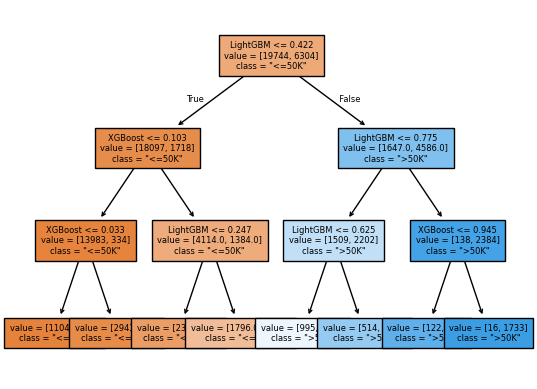

In [70]:
custom_plot_tree(stacking_model_tree.final_estimator_, 
                 feature_names=list(classifiers.keys()),
                 class_names=['"<=50K"', '">50K"'],
                 impurity=False,
                 fontsize=6)

#### An effective strategy

- **Randomly generate** a bunch of models with **different hyperparameter** configurations,<br> and then **stack all the models**.

<br>

#### Advantage and Disadvantage

- What is an advantage of ensembling multiple models as opposed to just choosing one of them?
    - You may get a **better score**.
- What is an disadvantage of ensembling multiple models as opposed to just choosing one of them?
    - **Slower**, more **code maintenance** issues.

There are equivalent regression models for all of these:

- `RandomForestClassifier` $\rightarrow$ [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- `LGBMClassifier` $\rightarrow$ [`LGBMRegressor`](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html)
- `XGBClassifier` $\rightarrow$ [`XGBRegressor`](https://xgboost.readthedocs.io/en/latest/python/python_api.html)
- `CatBoostClassifier` $\rightarrow$ `CatBoostRegressor`
- `VotingClassifier` $\rightarrow$ [`VotingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingRegressor.html)
- `StackingClassifier` $\rightarrow$ [`StackingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html)

Read documentation of each of these.

<br><br><br><br>

## Summary 

- You have a number of models in your toolbox now.  
- Ensembles are usually pretty effective.
  - Tree-based models are particularly popular and effective on a wide range of problems. 
  - But they trade off code complexity and speed for prediction accuracy.
  - Don't forget that hyperparameter optimization multiplies the slowness of the code!
- Stacking is a bit slower than voting, but generally higher accuracy.
  - As a bonus, you get to see the coefficients for each base classifier.
- All the above models have equivalent regression models.   

#### Relevant papers

- [Fernandez-Delgado et al. 2014](http://jmlr.org/papers/volume15/delgado14a/delgado14a.pdf) compared 179 classifiers on 121 datasets:
    - First best class of methods was Random Forest and second best class of methods was (RBF) SVMs.

- If you like to read original papers [here](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf) is the original paper on Random Forests by Leo Breiman. 
- [XGBoost, LightGBM or CatBoost — which boosting algorithm should I use?](https://medium.com/riskified-technology/xgboost-lightgbm-or-catboost-which-boosting-algorithm-should-i-use-e7fda7bb36bc)